<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/exp%204%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=========== EDGE DEVICE ===========
Current AQI : 146
Stored at Edge : 24

=========== CLOUD SERVER ===========
Cloud Records : 24
Mean AQI : 141.88
Moving Average : 142.0
Standard Deviation : 83.88
Status : UNHEALTHY FOR SENSITIVE GROUPS


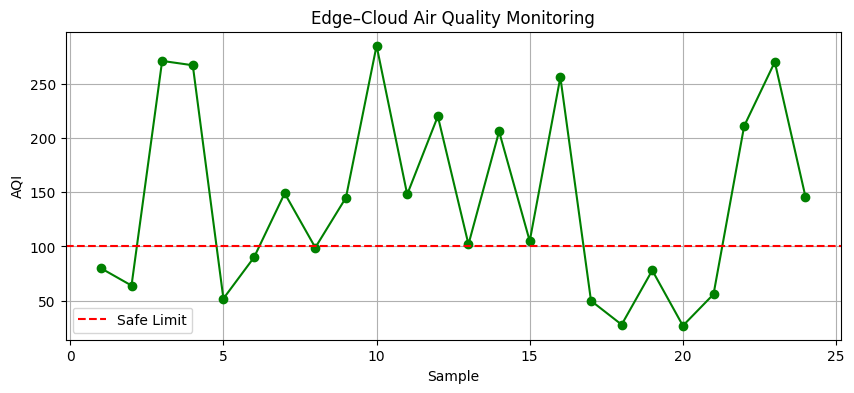

KeyboardInterrupt: 

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Edge and Cloud Storage
edge_storage = []
cloud_storage = []
time_data = []

# Simulate 50 AQI readings
for i in range(1, 51):

    # Random Air Quality Index (AQI)
    aqi = random.randint(20, 300)

    # Edge Storage
    edge_storage.append(aqi)

    # Synchronize to Cloud
    cloud_storage.append(aqi)

    time_data.append(i)

    # Statistics
    mean = np.mean(cloud_storage)
    std = np.std(cloud_storage)

    if len(cloud_storage) >= 5:
        moving = np.mean(cloud_storage[-5:])
    else:
        moving = mean

    # Air Quality Status
    if aqi <= 50:
        status = "GOOD AIR QUALITY"
    elif aqi <= 100:
        status = "MODERATE"
    elif aqi <= 150:
        status = "UNHEALTHY FOR SENSITIVE GROUPS"
    elif aqi <= 200:
        status = "UNHEALTHY"
    else:
        status = "VERY UNHEALTHY"

    # Clear previous output (Google Colab)
    clear_output(wait=True)

    print("=========== EDGE DEVICE ===========")
    print("Current AQI :", aqi)
    print("Stored at Edge :", len(edge_storage))
    print()

    print("=========== CLOUD SERVER ===========")
    print("Cloud Records :", len(cloud_storage))
    print("Mean AQI :", round(mean, 2))
    print("Moving Average :", round(moving, 2))
    print("Standard Deviation :", round(std, 2))
    print("Status :", status)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(time_data, cloud_storage, marker='o', color='green')
    plt.axhline(100, color='red', linestyle='--', label='Safe Limit')
    plt.xlabel("Sample")
    plt.ylabel("AQI")
    plt.title("Edge–Cloud Air Quality Monitoring")
    plt.grid(True)
    plt.legend()
    plt.show()

    time.sleep(0.5)

# Save to CSV
df = pd.DataFrame({
    "Sample": time_data,
    "AQI": cloud_storage
})

df.to_csv("cloud_air_quality_data.csv", index=False)

print("\nExperiment Completed Successfully")
print("CSV File Saved: cloud_air_quality_data.csv")